In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
import logging, sys
for h in logging.root.handlers[:]:
    logging.root.removeHandler(h)
logging.basicConfig(
    level=logging.ERROR,  # or DEBUG
    stream=sys.stdout,  # send logs to the cell output
    format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
)
logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
logging.captureWarnings(True)

# import logging
# logging.disable(logging.CRITICAL)

In [4]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

In [5]:
# def extract_fitted_curve_nodes(fitted_curve: ql.YieldTermStructure, num_points = 10000):
#     start_date: ql.Date = fitted_curve.referenceDate()
#     end_date: ql.Date = fitted_curve.maxDate()
#     grid_serials = np.linspace(start_date.serialNumber(), end_date.serialNumber(), num_points).astype(int)
#     grid_dates = [ql.Date(int(s)) for s in grid_serials]
#     return {ql_date_to_datetime(date): fitted_curve.discount(date) for date in grid_dates}

# qlirswapcurve = curve_mdp.get_data({"curve_name": "USD-SOFR-1D", "timestamp": datetime.date(2025, 9, 2)})
# h: ql.YieldTermStructureHandle = qlirswapcurve.handle()
# extract_fitted_curve_nodes(h)

In [23]:
q = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y")
df = irs_tb.get_timeseries(start=datetime.date(2025, 9, 1), end=datetime.date(2025, 9, 19), queries=[q], n_jobs=1, ignore_cache=True)
df

PRICING IRSWAPS...:   0%|          | 0/15 [00:00<?, ?it/s]

2025-09-20 18:04:11,932 ERROR [IRSwapsTB] Worker failed for curve='USD-SOFR-1D' on date='2025-09-01'.
Traceback (most recent call last):
  File "c:\Users\chris\clee\ARBS\TB\IRSwapsTB.py", line 110, in _worker_for_date
    curve = mdp.get_data({"curve_name": curve_name, "timestamp": ref_dt})
  File "c:\Users\chris\clee\ARBS\MDP\IRSwaps\IRSwapsMDP.py", line 100, in get_data
    return self._get_curve(curve_name, timestamp, kwargs=request)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chris\clee\ARBS\MDP\IRSwaps\IRSwapsMDP.py", line 106, in _get_curve
    assert not QUANTLIB_CURVE_DEFINITIONS[curve_name]["Calendar"].isHoliday(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        datetime_to_ql_date(timestamp)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ), f"{timestamp} is a holiday in the {QUANTLIB_CURVE_DEFINITIONS[curve_name]["Calendar"]}!"
    ^
AssertionError: 2025-09-01 is a holiday in the US government bond market c

PRICING IRSWAPS...: 100%|██████████| 15/15 [00:00<00:00, 155.96it/s]


,USD-SOFR-1D 10Y OUTRIGHT RATE
Date,
2025-09-02,3.730307
2025-09-03,3.670484
2025-09-04,3.637393
2025-09-05,3.554994
2025-09-08,3.511825
2025-09-09,3.540269
2025-09-10,3.506871
2025-09-11,3.485601
2025-09-12,3.527938


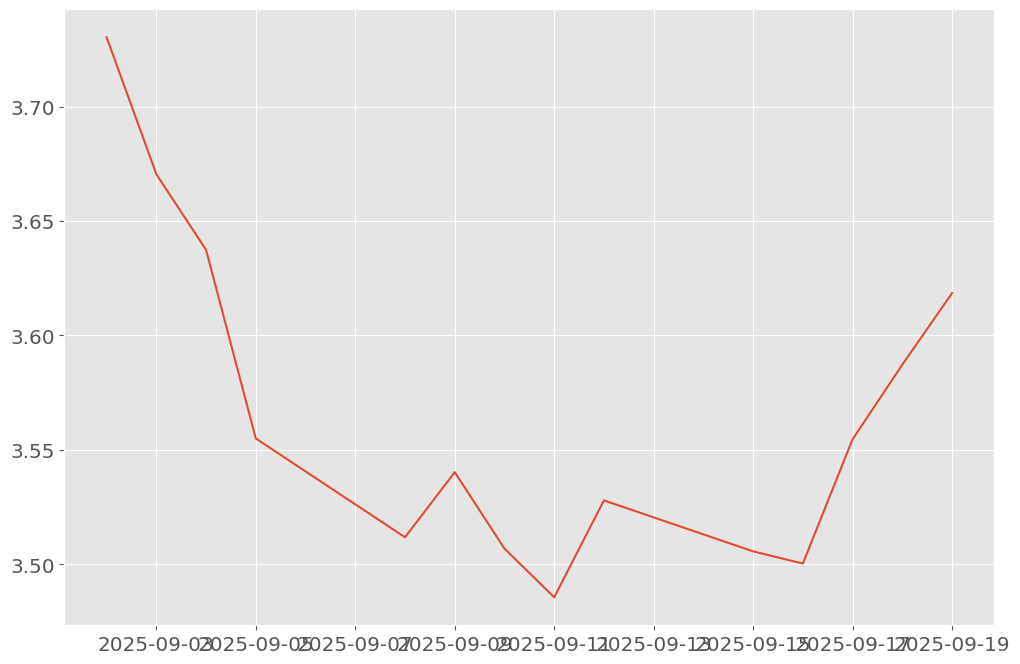

In [24]:
plt.plot(df.index, df[q.col_name()])

In [45]:
# timestamp = NY_tz.localize(datetime.datetime(2025, 9, 19, 15, 00))
# timestamp = NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00)) 
timestamp = datetime.date(2025, 9, 17)
# timestamp = "live" 

In [48]:
rlcurve = curve_mdp.get_data(curve_name="USD-SOFR-1D", timestamp=timestamp)
# rlcurve = rl_usd_sofr_mt_curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp="live")

TypeError: IRSwapMDP.get_data() got an unexpected keyword argument 'curve_name'

In [49]:
curve_mdp.source

'GSQUANT-rl_basic'

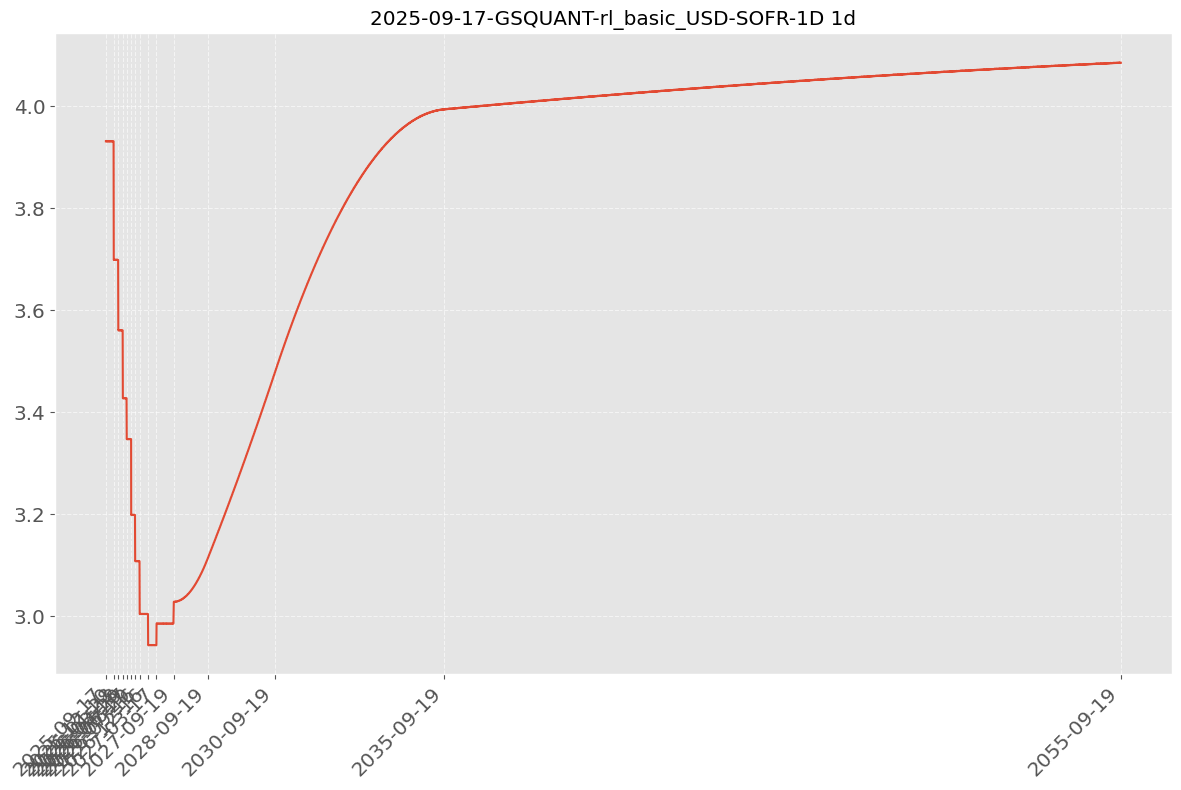

In [47]:
# x_data_num, y_data_rate = rl_sofr_curve._plot_rates("1D", left=rl.NoInput(0), right=rl.NoInput(0))
x_data_num, y_data_rate = rlcurve.handle()._plot_rates("1d", left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())


fig, ax = plt.subplots()
ax.plot(x_business_days, y_business_rates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")  # Rotate ticks for better readability
ax.grid(True, linestyle="--", alpha=0.6)

curve_nodes = rlcurve.handle().nodes._nodes.keys()
ticks = [t.tz_localize(None) if getattr(t, "tzinfo", None) else t for t in curve_nodes]
ax.set_xticks(mdates.date2num(ticks))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.title(f"{rlcurve.meta()["id"]} 1d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
fomc_dated_ois = {
    "sep25": (rl.dt(2025, 9, 17), rl.dt(2025, 10, 29)),
    "oct25": (rl.dt(2025, 10, 29), rl.dt(2025, 12, 10)),
    "dec25": (rl.dt(2025, 12, 10), rl.dt(2026, 1, 28)),
    "jan26": (rl.dt(2026, 1, 28), rl.dt(2026, 3, 18)),
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

In [98]:
build_fomc_ois(meeting="jun26", rl_curve=rlcurve.handle(), risk=50_000).rate()

<Dual: 3.237492, (2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x86, 2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x85, 2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x87, ...), [884.2, 0.0, -887.5, ...]>